### Linear NN for images

In [37]:
import tensorflow as tf

IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1


CLASS_NAMES = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [38]:
def read_and_scale(filename,resize_dims):
    # read file 
    image_bytes = tf.io.read_file(filename)
    
    # decode image bytes to tensor
    img=tf.image.decode_jpeg(image_bytes, channels=IMG_CHANNELS)
    
    # convert image to float32 and scale to [0,1]
    img=tf.image.convert_image_dtype(img, tf.float32)
    
    # resize image to target dimensions
    img=tf.image.resize(img, resize_dims)
    return img

In [39]:
def parse_csvline(csv_line):
    # record_defaults specify the data types for each column
    record_default = ["", ""]
    filename, label_string = tf.io.decode_csv(csv_line, record_default)

    # Load the image
    img = read_and_scale(filename, [IMG_HEIGHT, IMG_WIDTH])

    # Convert label string to integer based on the CLASS_NAMES index
    label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
    return img, label

In [40]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the full training data (60,000 images)
(X_all, y_all), (_, _) = fashion_mnist.load_data()

# 2. Shuffle the data randomly
indices = np.arange(len(X_all))
np.random.seed(42)  # Ensures you get the same shuffle every time
np.random.shuffle(indices)

X_all = X_all[indices]
y_all = y_all[indices]

# 3. Split into 180 training and 20 testing images
X_train_small = X_all[:180]
y_train_small = y_all[:180]

X_test_small = X_all[180:200]
y_test_small = y_all[180:200]

print(f"Small Training Set Shape: {X_train_small.shape}")  # (180, 28, 28)
print(f"Small Testing Set Shape: {X_test_small.shape}")    # (20, 28, 28)


Small Training Set Shape: (180, 28, 28)
Small Testing Set Shape: (20, 28, 28)


In [41]:
# 3. Create the tf.data pipelines matching your exact style
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train_small, y_train_small))
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test_small, y_test_small))
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

# Quick verification check
print("Train batches:", len(list(train_dataset))) # 180 samples / 16 batch size = 12 batches
print("Eval batches:", len(list(eval_dataset)))   # 20 samples / 16 batch size = 2 batches

Train batches: 12
Eval batches: 2


In [42]:
for image_batch, label_batch in eval_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 28, 28)
Label batch shape: (16,)
Labels: [6 5 8 5 9 2 0 9 4 6 3 2 3 0 1 7]


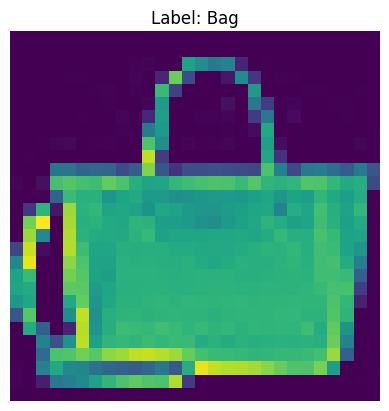

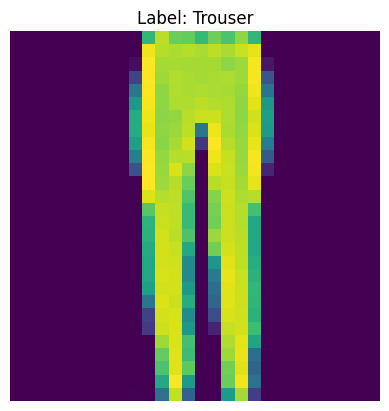

In [43]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

In [44]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [45]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/10


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.1012 - loss: 227.2023 - val_accuracy: 0.3000 - val_loss: 84.7651
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3270 - loss: 83.3695 - val_accuracy: 0.4500 - val_loss: 58.8874
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6277 - loss: 29.7618 - val_accuracy: 0.5000 - val_loss: 37.3468
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6654 - loss: 20.4052 - val_accuracy: 0.6500 - val_loss: 32.3883
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7448 - loss: 12.1458 - val_accuracy: 0.5000 - val_loss: 33.7810
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7568 - loss: 10.7407 - val_accuracy: 0.7500 - val_loss: 24.6439
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8028 - loss: 11.1032 - val_accuracy: 0.6000 - val_loss: 26.8809
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8459 - loss: 6.4688 - val_accuracy: 0.6000 - val_

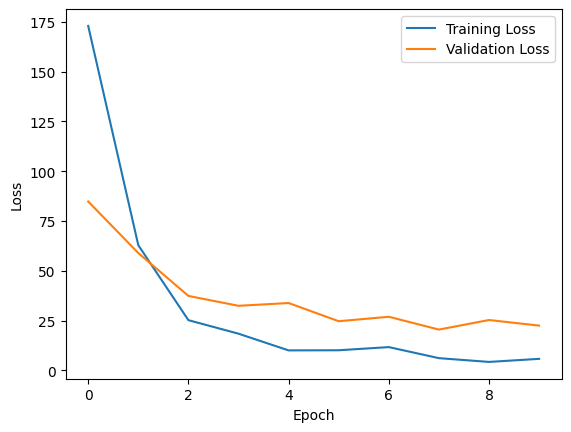

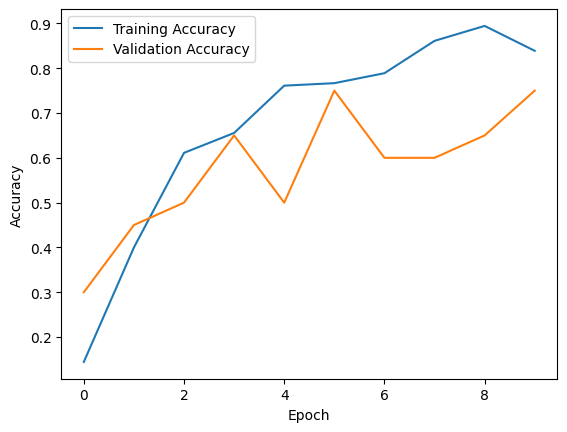

In [46]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


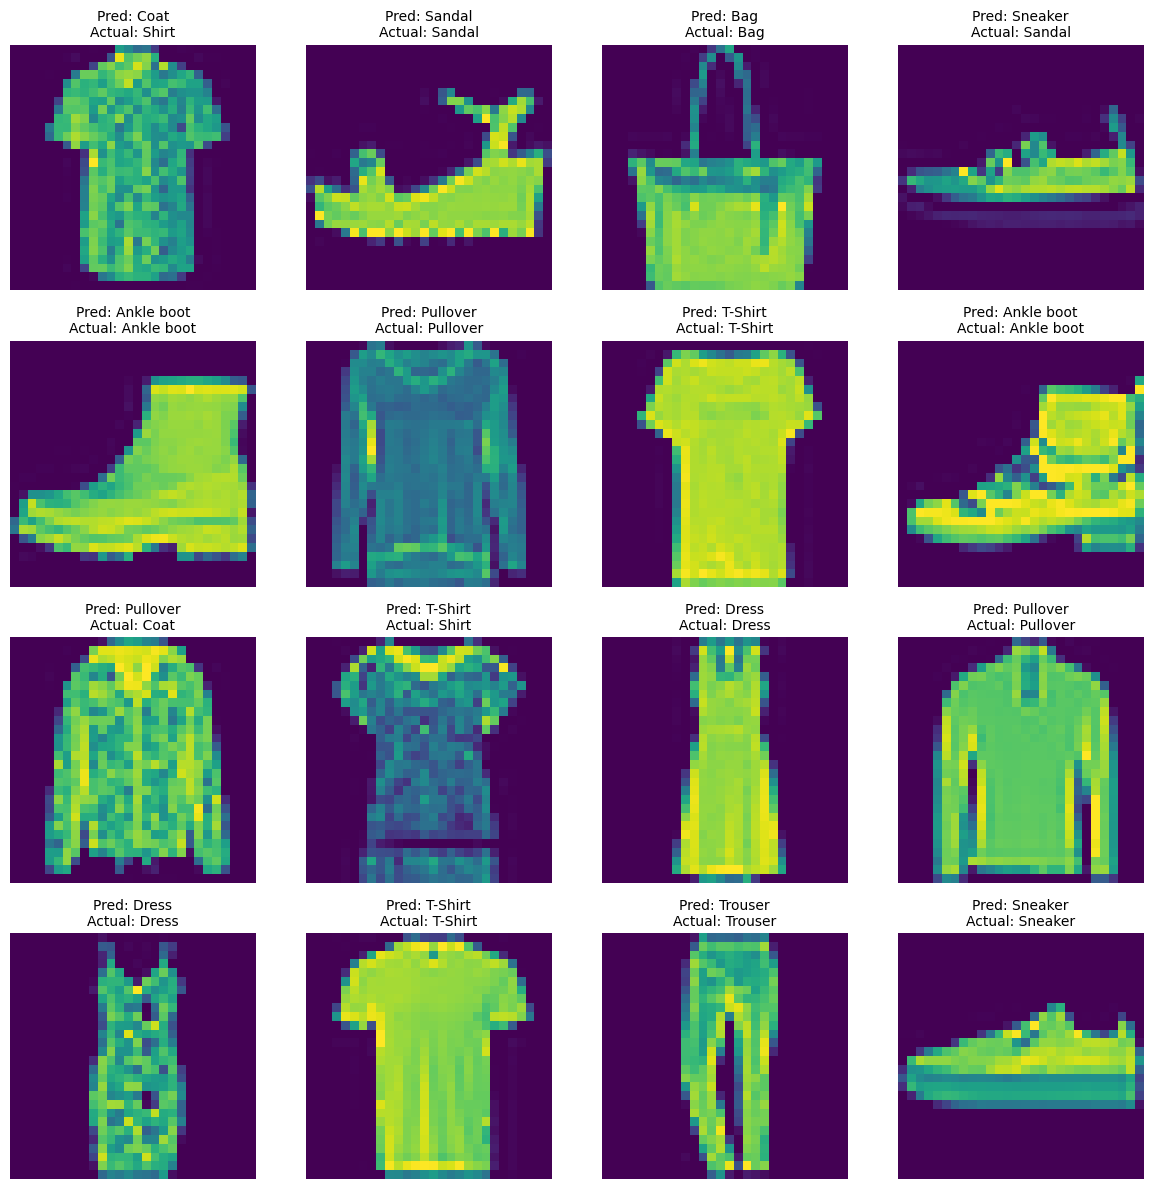

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in eval_dataset.take(1):
    # Get model predictions for this batch
    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

## Add Non-linearities to the model